In [1]:
# ============================================
# Zomato Restaurant Analytics — Bengaluru Data
# By: Arpita Smruti Subhalaxmi | Python for Data Analytics
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 11

print("All libraries loaded and style set!")

All libraries loaded and style set!


In [2]:
# ──  Dataset ────────────────────────────────────────────
data = {
    'name': ['Meghana Foods','CTR','Vidyarthi Bhavan','Truffles',
             'Empire Restaurant','Toit Brewpub',"Koshy's",'The Permit Room',
             "Brahmin's Coffee Bar",'Bounce','Fatty Bao',"Glen's Bakehouse",
             'Nagarjuna','Punjab Grill',"Fenny's",'Social',
             'The Black Pearl','Karavalli','By The Way','MTR'],
    'cuisine': ['Biryani','South Indian','South Indian','Continental',
               'North Indian','Pub','Continental','South Indian',
               'South Indian','Pub','Asian','Bakery',
               'Andhra','North Indian','Goan','Continental',
               'Seafood','Seafood','Cafe','South Indian'],
    'area': ['Koramangala','Malleshwaram','Basavanagudi','Koramangala',
            'Whitefield','Indiranagar','MG Road','Indiranagar',
            'Basavanagudi','Koramangala','Indiranagar','Koramangala',
            'Indiranagar','MG Road','Indiranagar','Koramangala',
            'Indiranagar','MG Road','Whitefield','Basavanagudi'],
    'rating':          [4.5,4.8,4.7,4.4,4.1,4.6,4.3,4.2,
                         4.6,4.0,4.3,4.5,4.2,4.1,3.9,4.0,
                         4.4,4.7,4.1,4.9],
    'votes':           [15420,8932,12100,22300,18900,31200,7800,9400,
                         6200,14300,18700,11200,9800,7600,5400,23400,
                         8900,12400,6700,19800],
    'avg_cost_for_two':[400,150,120,700,500,1200,600,800,
                         80,1500,1100,400,350,900,600,1000,
                         900,1500,300,200],
    'online_order':    ['Yes','No','No','Yes','Yes','Yes','No','Yes',
                         'No','Yes','Yes','Yes','Yes','No','No','Yes',
                         'Yes','No','Yes','No']
}

df = pd.DataFrame(data)

# Add engineered columns
df['price_range'] = pd.cut(df['avg_cost_for_two'],
    bins=[0,300,700,1200,9999],
    labels=['Budget','Mid-range','Premium','Luxury'])

df['popularity_score'] = np.round(df['rating'] * np.log1p(df['votes']), 2)

print(f"Dataset ready: {df.shape[0]} rows × {df.shape[1]} columns")
df.head(3)

Dataset ready: 20 rows × 9 columns


,name,cuisine,area,rating,votes,avg_cost_for_two,online_order,price_range,popularity_score
0,Meghana Foods,Biryani,Koramangala,4.5,15420,400,Yes,Mid-range,43.40
1,CTR,South Indian,Malleshwaram,4.8,8932,150,No,Budget,43.67
2,Vidyarthi Bhavan,South Indian,Basavanagudi,4.7,12100,120,No,Budget,44.18


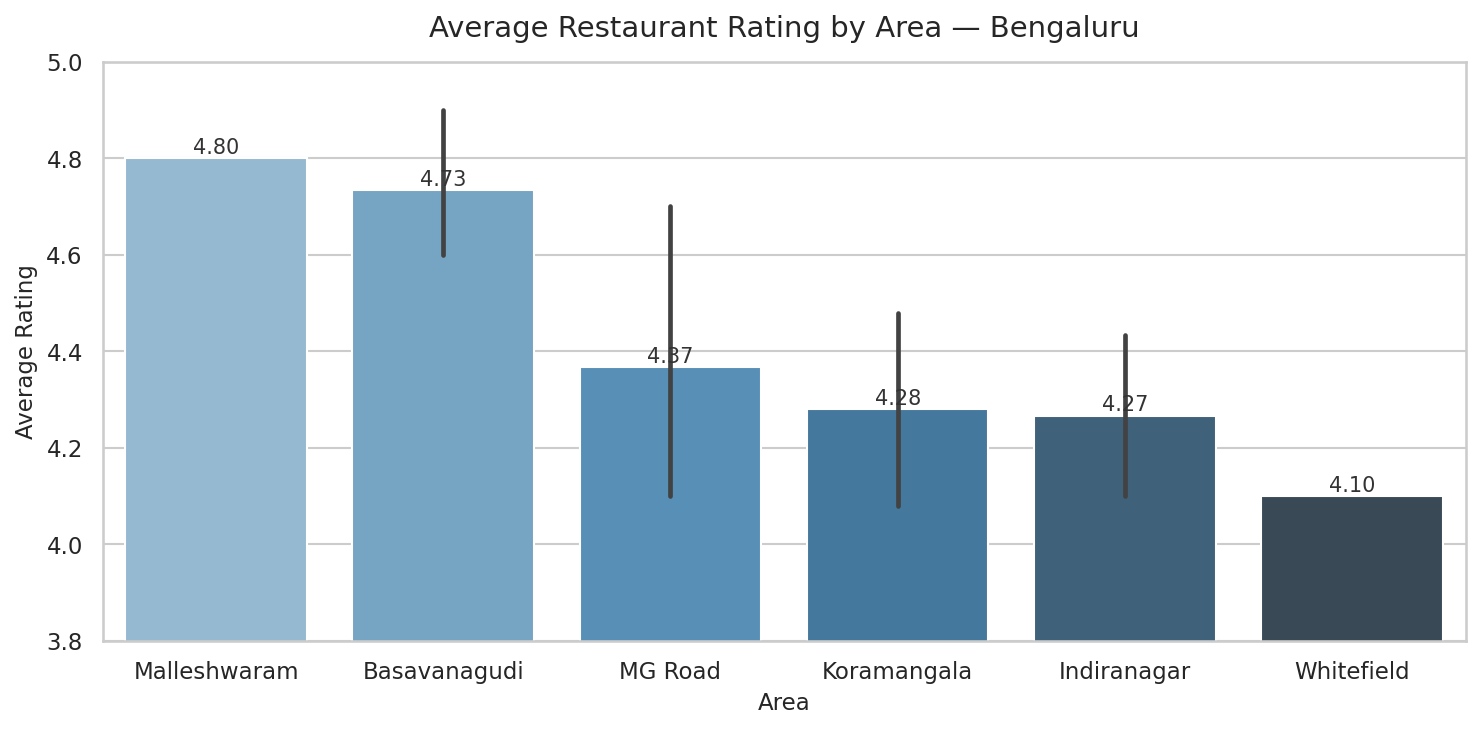

💡 Insight: Basavanagudi (home of MTR + Vidyarthi Bhavan) dominates!


In [3]:
# ── Bar Chart — Which area has the best restaurants? ───
fig, ax = plt.subplots(figsize=(10, 5))

area_order = (df.groupby('area')['rating']
                .mean()
                .sort_values(ascending=False)
                .index)

sns.barplot(
    data=df,
    x='area', y='rating',
    order=area_order,
    palette='Blues_d',
    ax=ax
)

ax.set_title('Average Restaurant Rating by Area — Bengaluru', fontsize=14, pad=12)
ax.set_xlabel('Area', fontsize=11)
ax.set_ylabel('Average Rating', fontsize=11)
ax.set_ylim([3.8, 5.0])

# Add value labels on top of each bar
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}",
                (p.get_x() + p.get_width() / 2, p.get_height() + 0.01),
                ha='center', fontsize=10, color='#333')

plt.tight_layout()
plt.savefig('chart1_area_ratings.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 Insight: Basavanagudi (home of MTR + Vidyarthi Bhavan) dominates!")

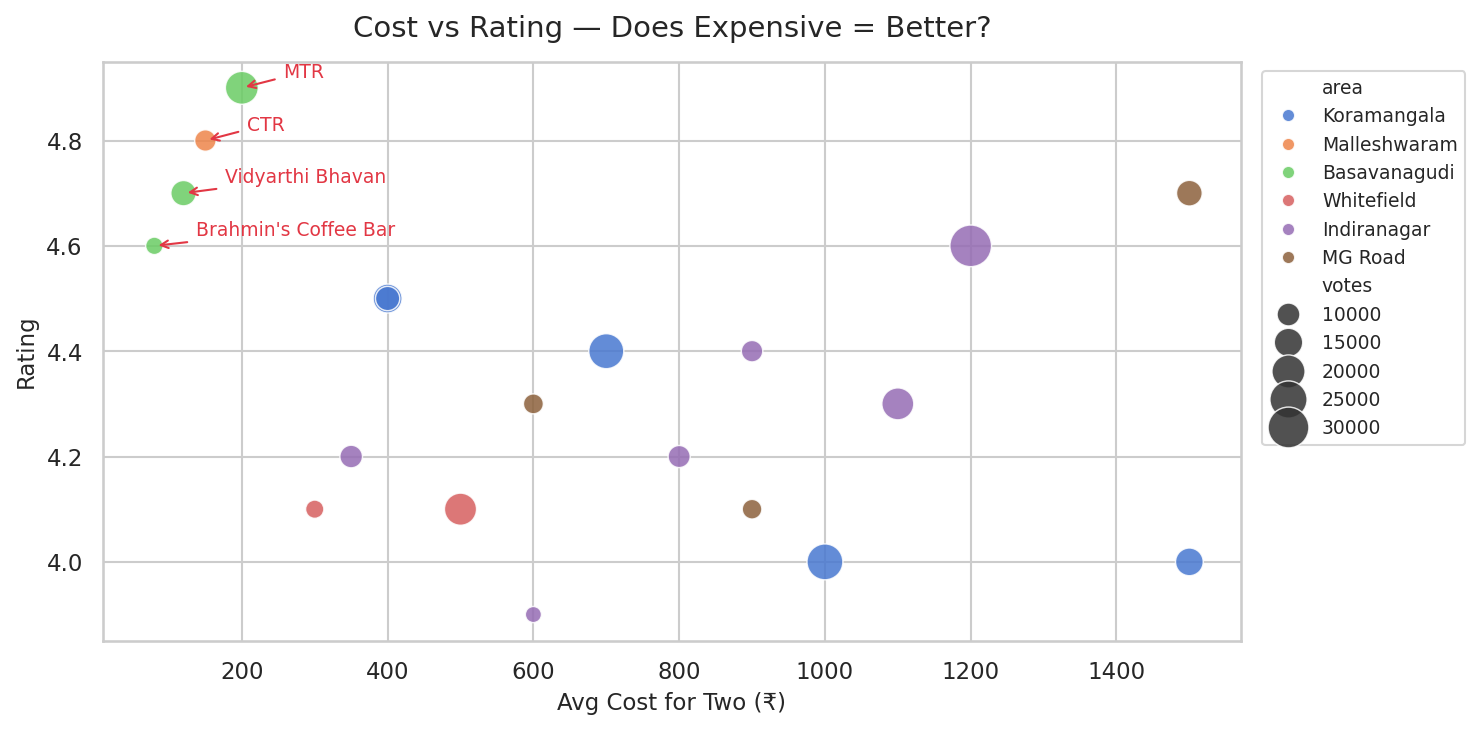

💡 Insight: No strong link! Brahmin's Coffee (₹80) beats most luxury spots.


In [4]:
# ── Scatter — Does spending more = better food? ────────
fig, ax = plt.subplots(figsize=(10, 5))

sns.scatterplot(
    data=df,
    x='avg_cost_for_two', y='rating',
    hue='area',
    size='votes', sizes=(60, 400),
    alpha=0.85,
    ax=ax
)

# Annotate outliers (best value finds)
best_value = df[(df['rating'] >= 4.5) & (df['avg_cost_for_two'] <= 300)]
for _, row in best_value.iterrows():
    ax.annotate(row['name'],
                xy=(row['avg_cost_for_two'], row['rating']),
                xytext=(20, 5), textcoords='offset points',
                fontsize=9, color='#e23744',
                arrowprops=dict(arrowstyle='->', color='#e23744', lw=1))

ax.set_title('Cost vs Rating — Does Expensive = Better?', fontsize=14, pad=12)
ax.set_xlabel('Avg Cost for Two (₹)', fontsize=11)
ax.set_ylabel('Rating', fontsize=11)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('chart2_cost_vs_rating.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 Insight: No strong link! Brahmin's Coffee (₹80) beats most luxury spots.")

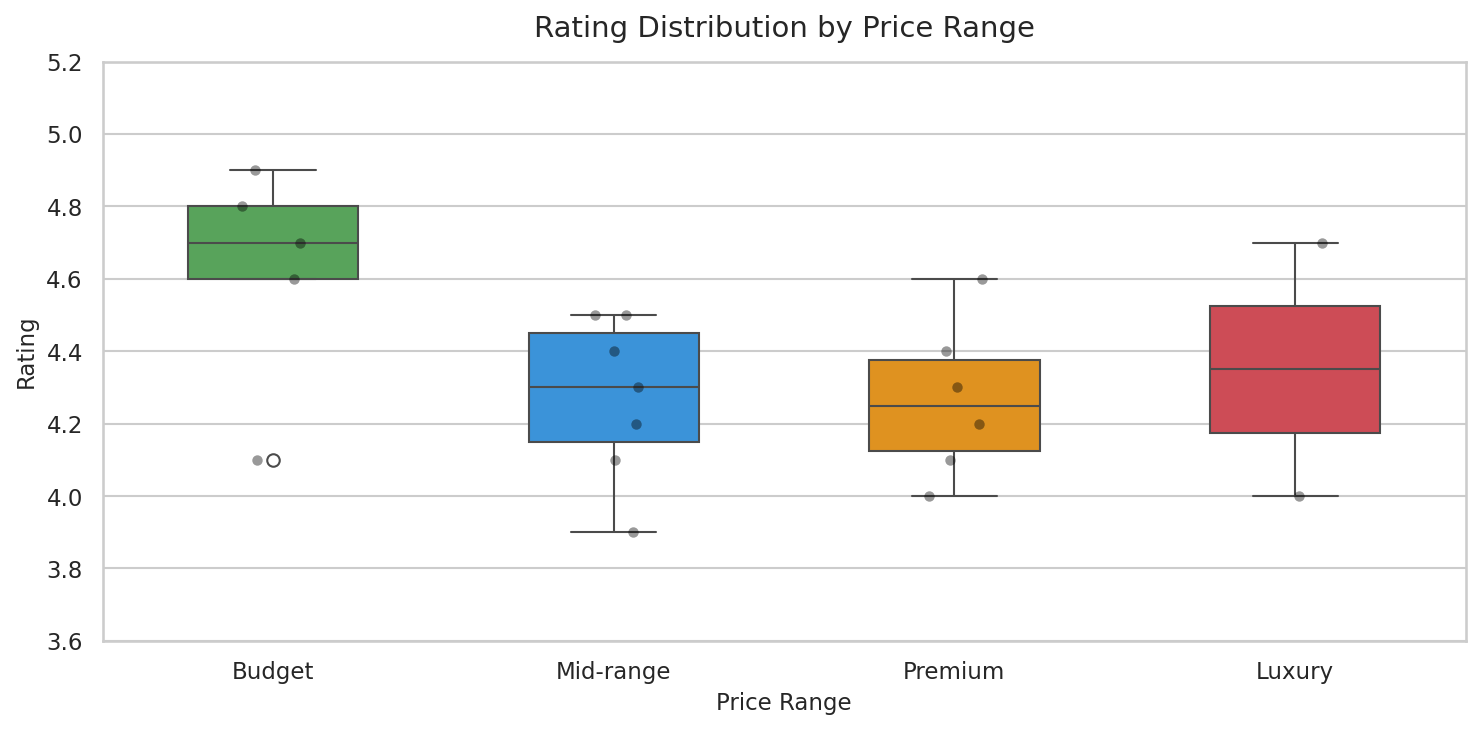

💡 Insight: Budget tier has the WIDEST spread — highest highs AND lowest lows.


In [5]:
# ── Box Plot — Rating spread across price tiers ────────
fig, ax = plt.subplots(figsize=(10, 5))

price_order = ['Budget', 'Mid-range', 'Premium', 'Luxury']
palette = {'Budget':'#4CAF50', 'Mid-range':'#2196F3',
           'Premium':'#FF9800', 'Luxury':'#e23744'}

sns.boxplot(
    data=df,
    x='price_range', y='rating',
    order=price_order,
    palette=palette,
    width=0.5,
    ax=ax
)

# Overlay individual data points (strip plot)
sns.stripplot(
    data=df,
    x='price_range', y='rating',
    order=price_order,
    color='black', alpha=0.4, size=5, jitter=True,
    ax=ax
)

ax.set_title('Rating Distribution by Price Range', fontsize=14, pad=12)
ax.set_xlabel('Price Range', fontsize=11)
ax.set_ylabel('Rating', fontsize=11)
ax.set_ylim([3.6, 5.2])

plt.tight_layout()
plt.savefig('chart3_rating_by_price.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 Insight: Budget tier has the WIDEST spread — highest highs AND lowest lows.")

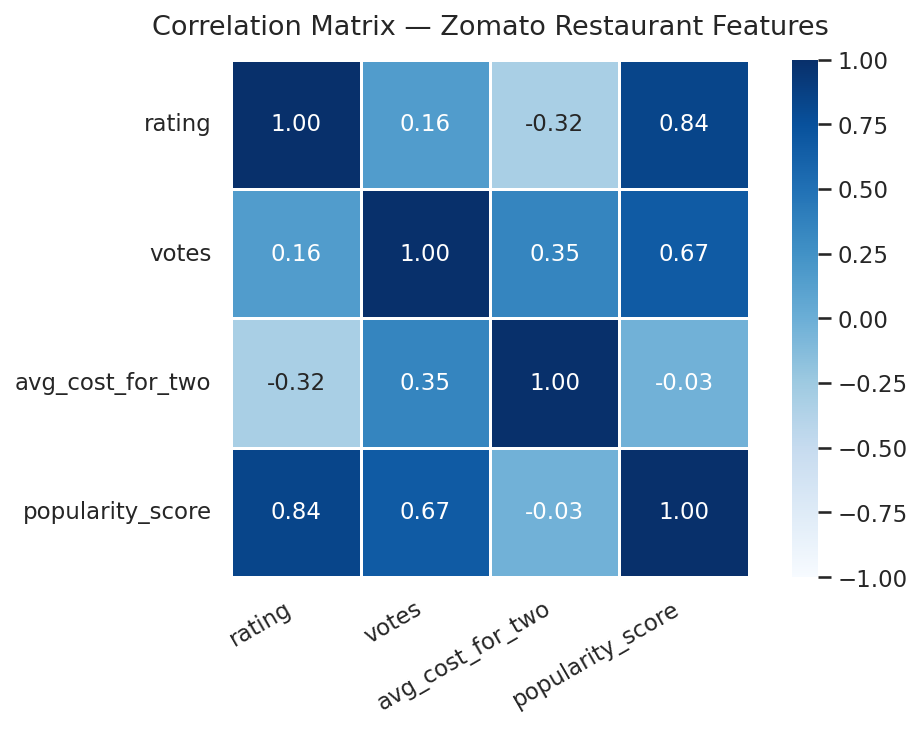

💡 Insight: Rating & popularity_score are highly correlated (expected!).
   Cost has near-zero correlation with rating — price ≠ quality.


In [6]:
# ── Heatmap — What's correlated with what? ─────────────
fig, ax = plt.subplots(figsize=(7, 5))

corr_cols = ['rating', 'votes', 'avg_cost_for_two', 'popularity_score']
corr_matrix = df[corr_cols].corr().round(2)

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    ax=ax
)

ax.set_title('Correlation Matrix — Zomato Restaurant Features', fontsize=13, pad=12)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('chart4_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("💡 Insight: Rating & popularity_score are highly correlated (expected!).")
print("   Cost has near-zero correlation with rating — price ≠ quality.")

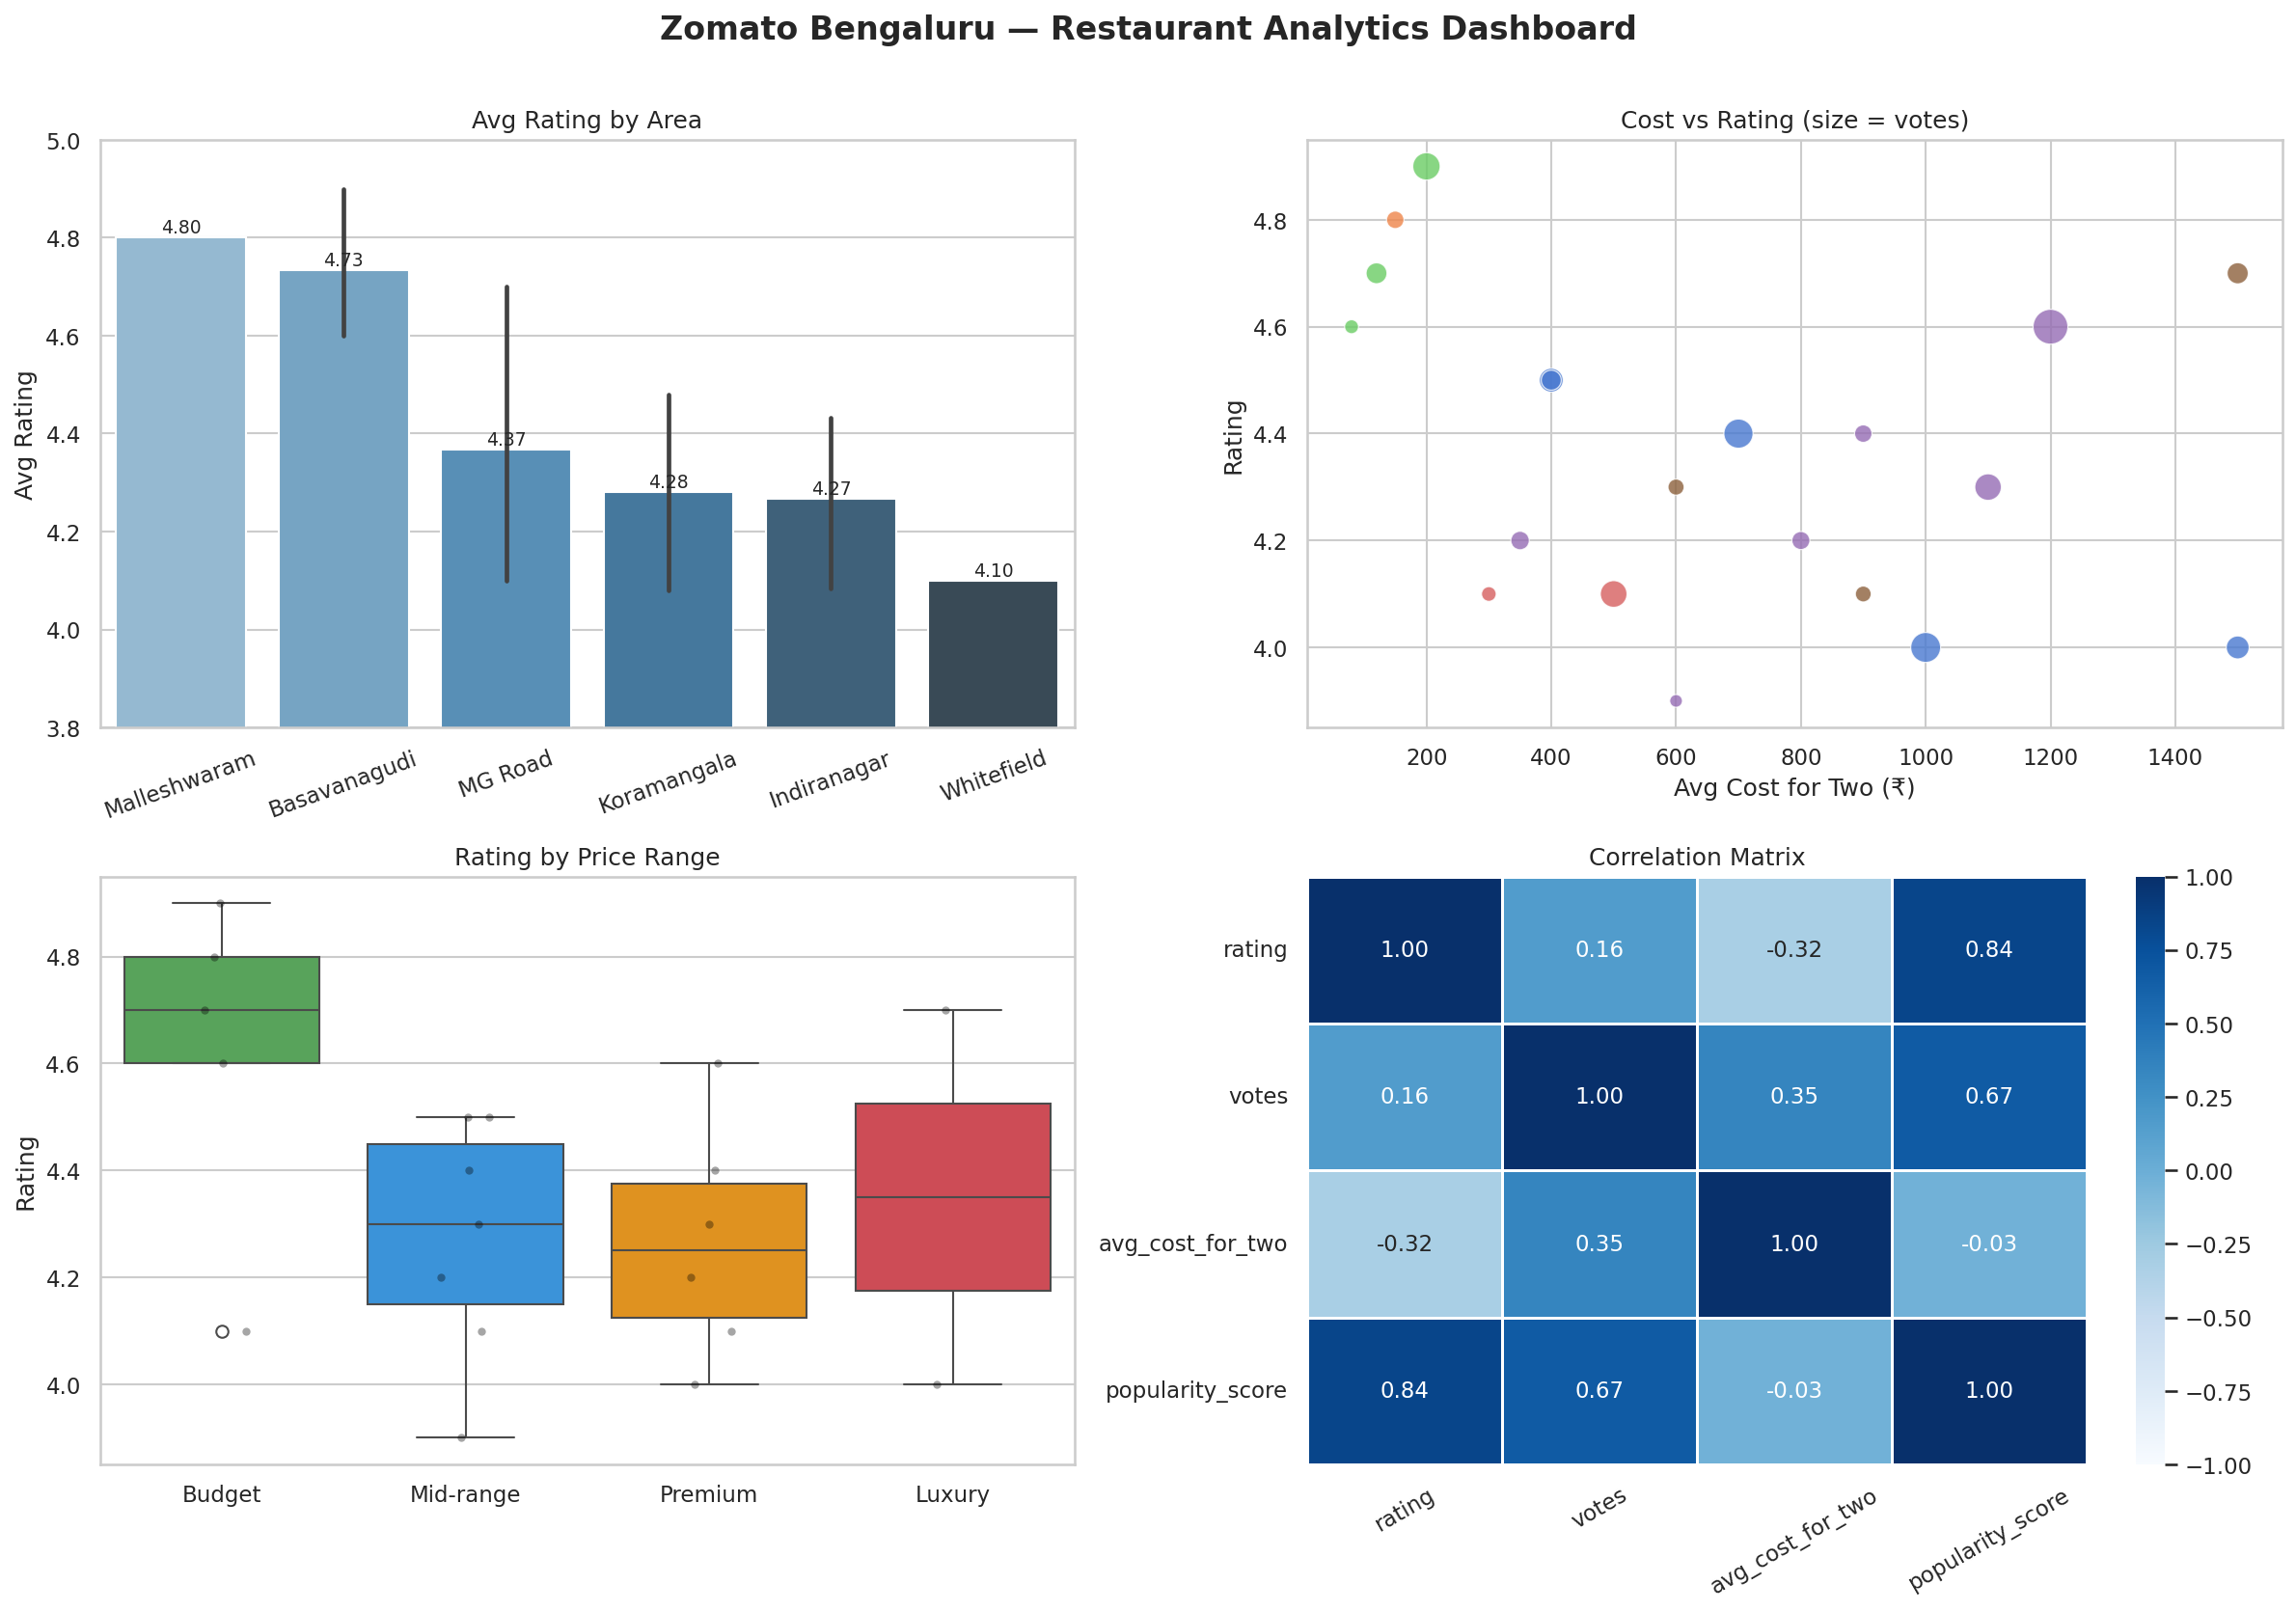

Dashboard saved as zomato_dashboard.png


In [7]:
# ──  2×2 Dashboard  ───────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Zomato Bengaluru — Restaurant Analytics Dashboard',
             fontsize=16, fontweight='bold', y=1.01)

# ── Plot 1 (top-left): Bar chart ───────────────────────────────
area_order = (df.groupby('area')['rating']
                .mean().sort_values(ascending=False).index)
sns.barplot(data=df, x='area', y='rating',
            order=area_order, palette='Blues_d', ax=axes[0,0])
axes[0,0].set_title('Avg Rating by Area', fontsize=12)
axes[0,0].set_xlabel(''); axes[0,0].set_ylabel('Avg Rating')
axes[0,0].set_ylim([3.8, 5.0])
axes[0,0].tick_params(axis='x', rotation=20)
for p in axes[0,0].patches:
    axes[0,0].annotate(f"{p.get_height():.2f}",
        (p.get_x()+p.get_width()/2, p.get_height()+0.01),
        ha='center', fontsize=9)

# ── Plot 2 (top-right): Scatter ────────────────────────────────
sns.scatterplot(data=df, x='avg_cost_for_two', y='rating',
               hue='area', size='votes', sizes=(40,300),
               alpha=0.8, ax=axes[0,1], legend=False)
axes[0,1].set_title('Cost vs Rating (size = votes)', fontsize=12)
axes[0,1].set_xlabel('Avg Cost for Two (₹)')
axes[0,1].set_ylabel('Rating')

# ── Plot 3 (bottom-left): Box plot ─────────────────────────────
price_order = ['Budget','Mid-range','Premium','Luxury']
sns.boxplot(data=df, x='price_range', y='rating',
            order=price_order,
            palette=['#4CAF50','#2196F3','#FF9800','#e23744'],
            ax=axes[1,0])
sns.stripplot(data=df, x='price_range', y='rating',
             order=price_order, color='black', alpha=0.35,
             size=4, ax=axes[1,0])
axes[1,0].set_title('Rating by Price Range', fontsize=12)
axes[1,0].set_xlabel(''); axes[1,0].set_ylabel('Rating')

# ── Plot 4 (bottom-right): Heatmap ─────────────────────────────
corr_cols = ['rating','votes','avg_cost_for_two','popularity_score']
sns.heatmap(df[corr_cols].corr().round(2),
            annot=True, fmt='.2f', cmap='Blues',
            vmin=-1, vmax=1, linewidths=0.5,
            ax=axes[1,1])
axes[1,1].set_title('Correlation Matrix', fontsize=12)
axes[1,1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('zomato_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved as zomato_dashboard.png")